# Project 2 — Visual Tracking Tutorial (Goalkeeper Assistant)

**Students:** Ahmad Osaid Majed, Alejandro Rafael Bordón Duarte


**Repo:** [https://github.com/alejandrord/visual-tracking-goalkeeper-assistant](https://github.com/alejandrord/visual-tracking-goalkeeper-assistant)


## 1. Real-world problem and motivation

### The problem: tracking fast-moving objects in sports video

Visual object tracking is one of the fundamental tasks in computer vision. It consists of locating a target object across consecutive frames of a video sequence, given only an initial detection or region of interest. While the problem statement is simple, real-world conditions such as occlusion, motion blur, illumination changes, and cluttered backgrounds make robust tracking a significant challenge.

In this project we focus on a concrete and compelling scenario: tracking the ball during penalty kicks in football. During a penalty, the goalkeeper has roughly 400–600 milliseconds to react after the ball is struck. At professional level, the ball can travel at speeds exceeding 100 km/h, which means it covers the 11-meter distance to the goal line in less than half a second. Any system that can detect the ball's trajectory in its earliest frames of flight could provide valuable cues for post-match analysis. By estimating trajectory, speed, and placement, teams can evaluate shot quality, goalkeeper reaction timing, and decision patterns. This improves player scouting, goalkeeper preparation, and tactical planning.

### Relevance to broader applications

Although our chosen scenario is in the sports domain, the underlying techniques generalize directly to several high-impact domains:

- **Traffic monitoring:** Intelligent transportation systems track vehicles at intersections and highways to estimate speed and count traffic. The fixed-camera assumption and the need to handle multiple moving objects under varying lighting are shared challenges (often solved with Background Subtraction techniques).

- **Autonomous driving and robotics:** Although these domains often use complex sensor fusion (LiDAR, radar), camera-based object tracking remains a core component for detecting pedestrians and cyclists.

- **Other sports analytics:** Beyond goalkeeping, ball and player tracking is used to compute possession statistics, heat maps, and tactical analysis. FIFA's semi-automated offside technology, for instance, relies on real-time ball tracking with high precision.


### Project goal

The goal of this notebook is to implement a robust tracking pipeline for penalty-kick clips. We adopt a two-stage approach:

1.  **Initialization (Part A):** We use MOG2 background subtraction combined with morphological operations and contour filtering to automatically detect the first reliable position of the moving ball. This solves the "initialization problem" without manual user input.
2.  **Tracking (Part B):** Once initialized, we hand off the coordinates to a tracker based on Template Matching and Lucas-Kanade Optical Flow to follow the ball through the rest of the trajectory, handling potential occlusions or detection failures.

## 2. Choice of tracking algorithms

Tracking a fast-moving ball in penalty-kick footage is a multi-faceted problem. After reviewing the visual tracking techniques studied in class (Topics 8–14), we selected four complementary methods that together form a robust detection-and-tracking pipeline. Each technique addresses a specific stage of the pipeline, and the choice is justified by the characteristics of our scenario: a fixed camera, a small and fast-moving ball, and a mostly static background.

Below we describe each selected algorithm, explain why it was chosen, and outline how it will be applied in this project.

---

### 2.1 Background Subtraction — MOG2

**What it does:**
Background subtraction classifies every pixel as either *foreground* (moving) or *background* (static) by maintaining a statistical model of the scene. The MOG2 (Mixture of Gaussians, version 2) algorithm, based on the work of Stauffer & Grimson (1999) and later improved by Zivkovic (2004), models each pixel's intensity history as a mixture of $K$ Gaussian distributions. Unlike the original MOG, MOG2 automatically adapts the number of Gaussians per pixel, which makes it better suited to scenes with varying complexity.

The probability of observing pixel value $X_t$ is:

$$P(X_t) = \sum_{i=1}^{K} \omega_{i,t} \cdot \mathcal{N}(X_t \mid \mu_{i,t}, \Sigma_{i,t})$$

where $\omega_{i,t}$ is the weight of the $i$-th Gaussian, $\mu_{i,t}$ its mean, and $\Sigma_{i,t}$ its covariance. The Gaussians are ranked by $\omega / \sigma$ and the first $B$ components whose cumulative weight exceeds a threshold $T$ form the background model.

**Why we chose it:**
- Our penalty-kick footage uses a fixed (or nearly fixed) camera, which is the ideal setting for background subtraction methods.
- MOG2 handlesmultimodal backgrounds well — it can cope with slight crowd movement and small illumination changes in the background without generating excessive false positives.
- It provides a clean binary foreground mask on which we can apply contour analysis to detect the ball.

**How we apply it:**
We apply MOG2 to the video frames and then use morphological operations (opening + closing with an elliptical kernel) to remove noise and consolidate blob regions. The cleaned mask is then passed to the contour analysis stage.

**OpenCV function:** `cv2.createBackgroundSubtractorMOG2()`

---

### 2.2 Contour Detection and Shape Filtering

**What it does:**
Once we have a foreground mask from MOG2, we need to extract individual objects and determine which one is the ball. **Contour detection** (`cv2.findContours`) identifies connected boundaries in a binary image. We then characterize each contour using geometric properties and a simple but highly effective shape descriptor — circularity:

$$\text{circularity} = \frac{4\pi \cdot \text{area}}{\text{perimeter}^2}$$

A perfect circle has a circularity of 1.0. The football, being roughly spherical in projection, yields high circularity values compared to other moving objects (players, referee, goalposts).

**Why we chose it:**
- The ball produces a **small, roughly circular** contour in the foreground mask, which is distinctive from other detected blobs (players are larger and more elongated, shadows are irregular).
- Filtering by **area range**, **aspect ratio**, and **circularity** provides an effective multi-criteria ball-candidate scoring system.
- Additional lightweight constraints (color/context priors) improve robustness in cluttered frames.

**How we apply it:**
For each contour found in the foreground mask, we compute its area, bounding rectangle aspect ratio, and circularity. Contours that fall outside the expected size range or fail the circularity threshold are discarded. The remaining candidate with the highest score is selected as the ball detection for that frame. Its centroid (computed from image moments $\bar{x} = m_{10}/m_{00}$, $\bar{y} = m_{01}/m_{00}$) becomes the initial detection used by the next stage.

**OpenCV functions:** `cv2.findContours()`, `cv2.moments()`, `cv2.contourArea()`, `cv2.arcLength()`, `cv2.boundingRect()`, `cv2.convexHull()`

El texto para la sección **2.3 Template Matching** es técnicamente correcto y define muy bien el algoritmo basándose en la fuente "12. Simple Template Matching.pdf". La fórmula del **NCC** (Normalized Correlation Coefficient) corresponde perfectamente con `cv2.TM_CCOEFF_NORMED` descrita en los documentos.

Sin embargo, tenemos **un error de consistencia grave** con nuestra estrategia de "Deadline Mode":

*   **El Error:** En la sección *"Why we chose it"*, mencionas: *"restricting the search to a small window around the **Kalman prediction**"*.
*   **La Corrección:** Como acordamos eliminar el Filtro de Kalman para simplificar, no puedes mencionar "Kalman prediction". Debes cambiarlo por "previous known position" (posición anterior conocida) o "optical flow prediction" (si Ahmad usa el flujo óptico para guiar el template).

Aquí tienes la versión corregida y segura para copiar, eliminando la referencia a Kalman pero manteniendo el rigor técnico:

---

### 2.3 Template Matching — NCC Verification

**What it does:**
Template matching slides a small reference image (the template) across the source image, computing a similarity score at every position. The **Normalized Correlation Coefficient (NCC)** variant is the most robust, as it is invariant to additive and multiplicative intensity changes:

$$R(x,y) = \frac{\sum_{x',y'} T'(x',y') \cdot I'(x+x', y+y')}{\sqrt{\sum_{x',y'} T'(x',y')^2 \cdot \sum_{x',y'} I'(x+x', y+y')^2}}$$

where $T'$ and $I'$ are mean-subtracted versions of the template and image patch. The output ranges from $-1$ (inverse match) to $+1$ (perfect match).

**Why we chose it:**
- Template matching provides a **direct appearance-based verification** of ball candidates, complementing the shape-based filtering of contour analysis.
- The NCC variant (`TM_CCOEFF_NORMED`) handles small lighting variations between frames effectively, which is important in broadcast footage.
- By restricting the search to a **small window around the last known position** (Region of Interest), the computational cost is negligible compared to searching the full frame.

**How we apply it:**
We extract a ball template from the initial confirmed detection (a small image patch around the centroid). In subsequent frames, we run `cv2.matchTemplate` with `TM_CCOEFF_NORMED` within a restricted search region centered on the ball's previous coordinates. If the NCC score exceeds a high threshold (e.g., 0.8), the match location is accepted as the new position. This re-verifies the tracking if the optical flow drifts.

**OpenCV function:** `cv2.matchTemplate()`

---

### 2.4 Lucas-Kanade Optical Flow — Sparse Point Tracking

**What it does:**
The **Lucas-Kanade** method estimates the motion (optical flow) of specific feature points between two consecutive frames. It assumes that all pixels within a small $N \times N$ window share the same displacement, yielding an overdetermined system solved by least squares:

$$\begin{bmatrix} V_x \\ V_y \end{bmatrix} = (A^T A)^{-1} A^T b$$

where $A$ contains the spatial gradients $I_x$, $I_y$ and $b$ contains the temporal gradients $-I_t$ for all pixels in the window. The **pyramidal** variant builds a multi-scale image pyramid to handle large displacements — computing flow at coarse resolution first and refining progressively.

**Why we chose it:**
- Lucas-Kanade is a **sparse** method — it tracks a small set of specific points rather than computing flow for every pixel. This is ideal for tracking a single small object (the ball) once its position is known.
- The pyramidal variant handles **large displacements**, which is critical for a ball moving at high speed between frames where the movement is larger than a few pixels.
- It acts as the **primary frame-to-frame tracker** after initialization. While MOG2 finds the ball initially, Optical Flow is better suited to follow it continuously without re-segmenting the whole image every frame.
- It is computationally efficient, adding minimal overhead to the pipeline.

**How we apply it:**
After the ball is detected in frame $t$ (either by MOG2 or Template Matching), we extract strong feature points using `cv2.goodFeaturesToTrack()` within a small mask around the detected centroid. In frame $t+1$, we compute their displacement with `cv2.calcOpticalFlowPyrLK()`. The median displacement of the successfully tracked points is added to the previous position to **update the ball's location** directly.

**OpenCV functions:** `cv2.calcOpticalFlowPyrLK()`, `cv2.goodFeaturesToTrack()`

---

## 3. Step-by-step tutorial
This section is intentionally minimal and focused on **one objective**: obtain the first reliable ball position using MOG2.

Scope of this simplified implementation:
- Input video is fixed to `penaltieshd.mp4`.
- Penalty windows are hardcoded in the notebook (no CSV reads).
- No manual ROI selection or external helper files.
- Output is a compact `init` dictionary that Ahmad can directly reuse.

### 3.1 Setup and hardcoded penalty windows
This cell imports the required libraries, validates the video path, defines the hardcoded penalty windows, and exposes a compact parameter dictionary (`BALL_CFG`).

Only the most relevant knobs are kept in the notebook:
- MOG2 tuning (`history`, `varThreshold`, `prewarm_seconds`, `kernel_size`).
- Ball candidate constraints (`area`, `circularity`, white thresholds, search band limits).
- Reliability checks (`min_score`, `min_hits`, `max_jump`, `max_fg_density`).

All secondary parameters are handled in `ball_detection_helpers.py` through internal defaults.


In [81]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

VIDEO_PATH = Path("penaltieshd.mp4")
assert VIDEO_PATH.exists(), f"Video not found: {VIDEO_PATH}"

PENALTIES = [
    {"name": "p1", "start_s": 2.0, "end_s": 5.0},
    {"name": "p2", "start_s": 6.0, "end_s": 8.0},
    {"name": "p3", "start_s": 9.0, "end_s": 11.0},
    {"name": "p4", "start_s": 12.0, "end_s": 13.0},
]

BALL_CFG = {
    "mog2_history": 220,
    "mog2_varThreshold": 28,
    "prewarm_seconds": 0.60,
    "kernel_size": 5,
    "min_area": 90,
    "max_area": 1800,
    "min_circularity": 0.45,
    "white_sat_max": 110,
    "white_val_min": 125,
    "x_center_band_ratio": 0.20,
    "y_min_ratio": 0.48,
    "y_max_ratio": 0.92,
    "min_score": 0.58,
    "min_hits": 2,
    "max_jump": 60,
    "max_fg_density": 0.12,
}

cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), f"Could not open {VIDEO_PATH}"
FPS = cap.get(cv2.CAP_PROP_FPS) or 30.0
N_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f"Video: {VIDEO_PATH} | FPS={FPS:.2f} | Frames={N_FRAMES}")
print("Hardcoded penalty ranges:")
for p in PENALTIES:
    print(f"  {p['name']}: {p['start_s']:.1f}s -> {p['end_s']:.1f}s")


Video: penaltieshd.mp4 | FPS=60.00 | Frames=833
Hardcoded penalty ranges:
  p1: 2.0s -> 5.0s
  p2: 6.0s -> 8.0s
  p3: 9.0s -> 11.0s
  p4: 12.0s -> 13.0s


### 3.2 Initial ball detection with MOG2 (Part A: helper functions)
To keep the notebook concise for presentation, helper logic is moved to `ball_detection_helpers.py`.

Imported helpers:
- `build_detection_config`: merges compact notebook overrides with internal defaults.
- `build_clean_foreground_mask`: MOG2 + morphology for a stable motion mask.
- `get_active_video_bounds`: detects the central active strip (ignores black side bars).
- `select_best_ball_candidate`: scores white circular candidates on grass with center/height priors.
- `draw_ball_marker`: visualization helper for clear overlays in section 3.4.


In [82]:
from importlib import reload
import ball_detection_helpers

reload(ball_detection_helpers)

from ball_detection_helpers import (
    build_detection_config,
    build_clean_foreground_mask,
    get_active_video_bounds,
    select_best_ball_candidate,
    draw_ball_marker,
)


### 3.2 Initial ball detection with MOG2 (Part B: main detector)
This second cell defines `find_first_ball_detection`, the main function used in the notebook.

Important reliability points:
- It primes video seeking before jumping to later windows (important for this codec).
- It pre-warms MOG2 before each range.
- It tracks candidate consistency across frames (`min_hits`, `max_jump`).
- It still returns the best rejected candidate when no reliable hit is accepted.


In [83]:
def find_first_ball_detection(video_path, start_s, end_s, cfg=None, verbose=True):
    """Return first reliable ball detection in [start_s, end_s] using MOG2-supported filtering."""
    cfg = build_detection_config(BALL_CFG if cfg is None else cfg)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        msg = f"Could not open video: {video_path}"
        if verbose:
            print(msg)
        return None, {"message": msg, "best_candidate": None}

    # Prime decoder once: seeking to late frames is unstable in this file otherwise.
    ok_prime, _ = cap.read()
    if not ok_prime:
        cap.release()
        msg = f"Could not read first frame from {video_path}"
        if verbose:
            print(msg)
        return None, {"message": msg, "best_candidate": None}

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    start_f = max(0, int(round(start_s * fps)))
    end_f = min(total_frames - 1, int(round(end_s * fps)))

    if end_f <= start_f:
        cap.release()
        msg = f"Invalid range: {start_s:.2f}s-{end_s:.2f}s"
        if verbose:
            print(msg)
        return None, {"message": msg, "best_candidate": None}

    mog2 = cv2.createBackgroundSubtractorMOG2(
        history=cfg["mog2_history"],
        varThreshold=cfg["mog2_varThreshold"],
        detectShadows=cfg["mog2_detectShadows"],
    )
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (cfg["kernel_size"], cfg["kernel_size"]),
    )

    prewarm_frames = int(round(cfg["prewarm_seconds"] * fps))
    prewarm_start = max(0, start_f - prewarm_frames)
    cap.set(cv2.CAP_PROP_POS_FRAMES, prewarm_start)
    for _ in range(prewarm_start, start_f):
        ret, frame = cap.read()
        if not ret:
            break
        _ = build_clean_foreground_mask(mog2, frame, kernel, learning_rate=cfg["prewarm_lr"])

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_f)

    prev_center = None
    streak = 0
    seen = 0
    frame_i = start_f
    best_fallback = None

    while frame_i <= end_f:
        ret, frame = cap.read()
        if not ret:
            break

        lr = cfg["warmup_lr"] if seen < cfg["warmup_frames"] else cfg["run_lr"]
        fg = build_clean_foreground_mask(mog2, frame, kernel, learning_rate=lr)
        fg_density = float(np.mean(fg > 0))

        best = select_best_ball_candidate(frame, fg, cfg)

        if best is not None:
            best["frame"] = int(frame_i)
            best["fg_density"] = float(fg_density)
            if best_fallback is None or best["score"] > best_fallback["score"]:
                best_fallback = {
                    **best,
                    "frame_bgr": frame.copy(),
                    "mask": fg.copy(),
                }

        reliable = (
            best is not None
            and best["score"] >= cfg["min_score"]
            and fg_density <= cfg["max_fg_density"]
        )

        if reliable:
            center = np.array([best["x"], best["y"]], dtype=np.float32)
            if prev_center is not None and np.linalg.norm(center - prev_center) <= cfg["max_jump"]:
                streak += 1
            else:
                streak = 1
            prev_center = center

            if streak >= cfg["min_hits"]:
                init = {
                    "frame": int(frame_i),
                    "x": int(best["x"]),
                    "y": int(best["y"]),
                    "confidence": round(float(min(best["score"], 1.0)), 3),
                    "bbox": best["bbox"],
                    "radius": int(best["radius"]),
                }
                debug = {
                    "frame_bgr": frame.copy(),
                    "mask": fg.copy(),
                    "bbox": best["bbox"],
                    "center": (best["x"], best["y"]),
                    "fg_density": float(fg_density),
                    "active_bounds": best["active_bounds"],
                    "best_candidate": {
                        "frame": int(best["frame"]),
                        "x": int(best["x"]),
                        "y": int(best["y"]),
                        "score": float(best["score"]),
                        "fg_density": float(fg_density),
                    },
                }
                cap.release()
                if verbose:
                    print(
                        f"Detection at frame {init['frame']} "
                        f"({init['x']}, {init['y']}) conf={init['confidence']:.3f}"
                    )
                return init, debug
        else:
            streak = 0
            prev_center = None

        frame_i += 1
        seen += 1

    cap.release()
    msg = f"No reliable detection in {start_s:.2f}s-{end_s:.2f}s"

    debug = {"message": msg, "best_candidate": None}
    if best_fallback is not None:
        debug.update(
            {
                "frame_bgr": best_fallback["frame_bgr"],
                "mask": best_fallback["mask"],
                "bbox": best_fallback["bbox"],
                "center": (best_fallback["x"], best_fallback["y"]),
                "active_bounds": best_fallback.get("active_bounds"),
                "best_candidate": {
                    "frame": int(best_fallback["frame"]),
                    "x": int(best_fallback["x"]),
                    "y": int(best_fallback["y"]),
                    "score": float(best_fallback["score"]),
                    "fg_density": float(best_fallback["fg_density"]),
                },
            }
        )
        msg = (
            f"{msg}. Best rejected candidate: frame={best_fallback['frame']} "
            f"x={best_fallback['x']} y={best_fallback['y']} "
            f"score={best_fallback['score']:.3f} fg_density={best_fallback['fg_density']:.4f}"
        )

    if verbose:
        print(msg)
    debug["message"] = msg
    return None, debug


### 3.3 Demo run
This cell runs the detector on all four hardcoded penalty windows (p1 to p4), without stopping at the first hit.

For each penalty, it prints either:
- a reliable initialization (`frame`, `x`, `y`, `confidence`), or
- a "not found" result with the best rejected candidate for diagnosis.

It keeps all runs in `penalty_runs` for section 3.4 and still exposes `init` as the first valid initialization for handoff compatibility.


In [84]:
init = None
debug_info = None
used_penalty = None
penalty_runs = []

for p in PENALTIES:
    print(f"\nTrying {p['name']} ({p['start_s']:.1f}s-{p['end_s']:.1f}s)")
    det, dbg = find_first_ball_detection(
        video_path=VIDEO_PATH,
        start_s=p["start_s"],
        end_s=p["end_s"],
        cfg=BALL_CFG,
        verbose=True,
    )

    if det is not None:
        det["penalty"] = p["name"]

    penalty_runs.append(
        {
            "name": p["name"],
            "start_s": p["start_s"],
            "end_s": p["end_s"],
            "init": det,
            "debug": dbg,
        }
    )

    if init is None and det is not None:
        init = det
        debug_info = dbg
        used_penalty = p

print("\nSummary for all penalties:")
for r in penalty_runs:
    if r["init"] is None:
        best = r["debug"].get("best_candidate")
        if best is None:
            print(f"  {r['name']} ({r['start_s']:.1f}s-{r['end_s']:.1f}s): not found")
        else:
            print(
                f"  {r['name']} ({r['start_s']:.1f}s-{r['end_s']:.1f}s): not found | "
                f"best rejected frame={best['frame']} x={best['x']} y={best['y']} "
                f"score={best['score']:.3f} density={best['fg_density']:.4f}"
            )
    else:
        d = r["init"]
        print(
            f"  {r['name']} ({r['start_s']:.1f}s-{r['end_s']:.1f}s): "
            f"frame={d['frame']} x={d['x']} y={d['y']} conf={d['confidence']:.3f}"
        )

if init is None:
    print("\nNo initial detection found in the four hardcoded ranges.")
else:
    print("\nFirst valid initialization:")
    print(init)
    print(f"Used range: {used_penalty['name']} ({used_penalty['start_s']}s-{used_penalty['end_s']}s)")



Trying p1 (2.0s-5.0s)
Detection at frame 121 (979, 576) conf=0.770

Trying p2 (6.0s-8.0s)
Detection at frame 361 (825, 800) conf=0.633

Trying p3 (9.0s-11.0s)
Detection at frame 541 (942, 734) conf=0.802

Trying p4 (12.0s-13.0s)
Detection at frame 721 (972, 578) conf=0.790

Summary for all penalties:
  p1 (2.0s-5.0s): frame=121 x=979 y=576 conf=0.770
  p2 (6.0s-8.0s): frame=361 x=825 y=800 conf=0.633
  p3 (9.0s-11.0s): frame=541 x=942 y=734 conf=0.802
  p4 (12.0s-13.0s): frame=721 x=972 y=578 conf=0.790

First valid initialization:
{'frame': 121, 'x': 979, 'y': 576, 'confidence': 0.77, 'bbox': (966, 560, 28, 34), 'radius': 17, 'penalty': 'p1'}
Used range: p1 (2.0s-5.0s)


### 3.4 Debug visualization (all four penalties)
This cell visualizes all four penalty windows in a single grid with explicit ball markers:
- Large circle + crosshair + text label for the detected center.
- Search area overlay (center band and y-range) used by the detector.
- Mask panel from MOG2 for the same frame.

If a penalty is rejected, the plot shows the best rejected candidate in orange.


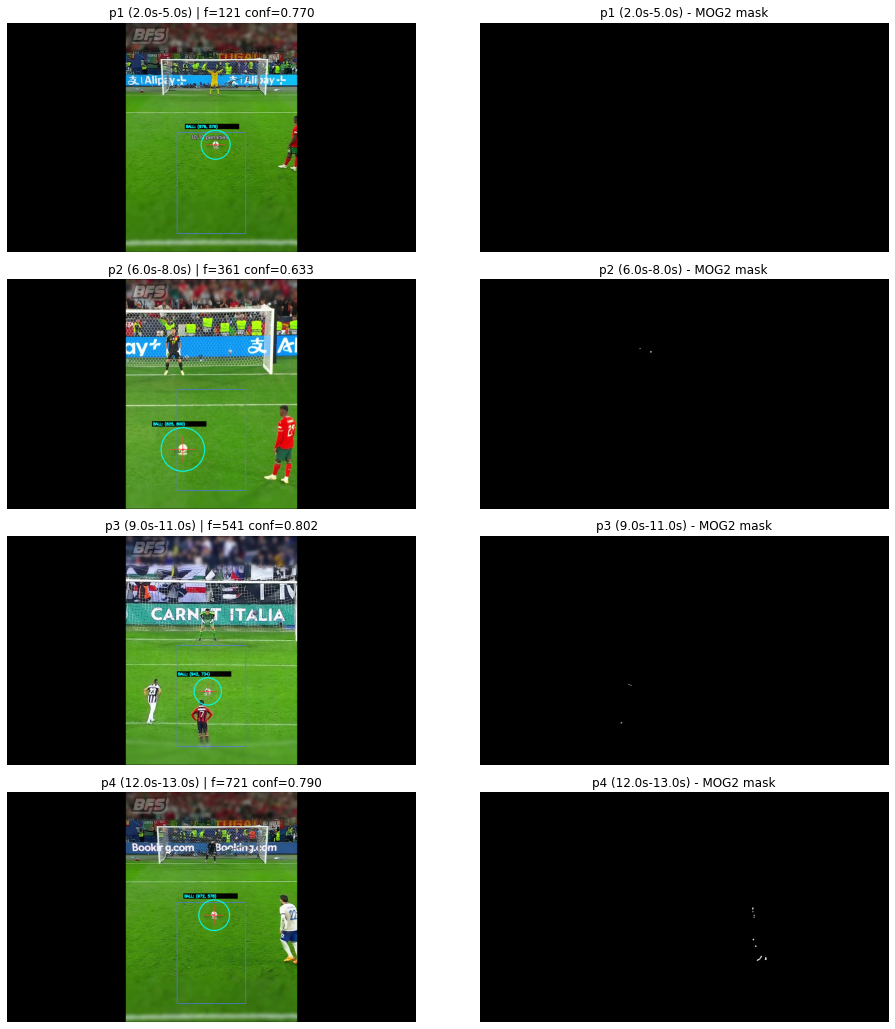

In [85]:
viz_cfg = build_detection_config(BALL_CFG)

if not penalty_runs:
    print("Nothing to visualize.")
else:
    n = len(penalty_runs)
    fig, axes = plt.subplots(n, 2, figsize=(14, 3.6 * n))
    if n == 1:
        axes = np.array([axes])

    for row, r in enumerate(penalty_runs):
        ax_frame = axes[row, 0]
        ax_mask = axes[row, 1]
        label = f"{r['name']} ({r['start_s']:.1f}s-{r['end_s']:.1f}s)"

        dbg = r.get("debug", {})

        if r["init"] is not None:
            d = r["init"]
            frame_rgb = cv2.cvtColor(dbg["frame_bgr"], cv2.COLOR_BGR2RGB)
            mask = dbg["mask"]
            x, y, w, h = d["bbox"]

            vis = frame_rgb.copy()
            left, right = dbg.get("active_bounds", get_active_video_bounds(dbg["frame_bgr"], viz_cfg["content_black_thresh"]))
            cx = 0.5 * (left + right)
            band = viz_cfg["x_center_band_ratio"] * (right - left)
            y0 = int(viz_cfg["y_min_ratio"] * vis.shape[0])
            y1 = int(viz_cfg["y_max_ratio"] * vis.shape[0])
            cv2.rectangle(vis, (int(cx - band), y0), (int(cx + band), y1), (80, 120, 255), 2)

            draw_ball_marker(vis, d["x"], d["y"], d["bbox"], "BALL", color=(0, 255, 255))

            ax_frame.imshow(vis)
            ax_frame.set_title(f"{label} | f={d['frame']} conf={d['confidence']:.3f}")
            ax_frame.axis("off")

            ax_mask.imshow(mask, cmap="gray")
            ax_mask.set_title(f"{label} - MOG2 mask")
            ax_mask.axis("off")
            continue

        best = dbg.get("best_candidate")
        has_fallback = (
            best is not None
            and dbg.get("frame_bgr") is not None
            and dbg.get("mask") is not None
            and dbg.get("bbox") is not None
            and dbg.get("center") is not None
        )

        if not has_fallback:
            ax_frame.text(0.5, 0.5, f"{label}\nNo reliable detection", ha="center", va="center", fontsize=10)
            ax_frame.set_title(f"{label} - Frame")
            ax_frame.axis("off")

            ax_mask.text(0.5, 0.5, "No mask available", ha="center", va="center", fontsize=10)
            ax_mask.set_title(f"{label} - MOG2 mask")
            ax_mask.axis("off")
            continue

        frame_rgb = cv2.cvtColor(dbg["frame_bgr"], cv2.COLOR_BGR2RGB)
        mask = dbg["mask"]
        x, y, w, h = dbg["bbox"]
        cx_b, cy_b = dbg["center"]

        vis = frame_rgb.copy()
        left, right = dbg.get("active_bounds", get_active_video_bounds(dbg["frame_bgr"], viz_cfg["content_black_thresh"]))
        cx = 0.5 * (left + right)
        band = viz_cfg["x_center_band_ratio"] * (right - left)
        y0 = int(viz_cfg["y_min_ratio"] * vis.shape[0])
        y1 = int(viz_cfg["y_max_ratio"] * vis.shape[0])
        cv2.rectangle(vis, (int(cx - band), y0), (int(cx + band), y1), (80, 120, 255), 2)

        draw_ball_marker(vis, cx_b, cy_b, dbg["bbox"], "REJECTED", color=(255, 180, 0))

        ax_frame.imshow(vis)
        ax_frame.set_title(
            f"{label} | rejected f={best['frame']} s={best['score']:.3f} d={best['fg_density']:.4f}"
        )
        ax_frame.axis("off")

        ax_mask.imshow(mask, cmap="gray")
        ax_mask.set_title(f"{label} - rejected candidate mask")
        ax_mask.axis("off")

    plt.tight_layout()


In [93]:
import cv2

cap = cv2.VideoCapture("penaltieshd.mp4")

for i in range(499):
    ret, frame = cap.read()
    if not ret:
        print("Failed before reaching target frame")
        break

cap.release()

roi = cv2.selectROI("Select Ball", frame, fromCenter=False, showCrosshair=True)
x, y, w, h = roi

template = frame[y:y+h, x:x+w]

cv2.imwrite("ball_in_motion.png", template)

cap.release()
cv2.destroyAllWindows()

(41, 22, 3)


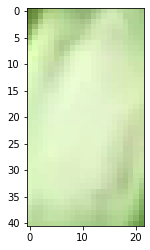

interactive(children=(BoundedIntText(value=0, description='frame_num', max=832), FloatSlider(value=0.7, descri…

<function __main__.show_template_match(frame_num, threshold)>

In [102]:
from ipywidgets import interact, BoundedIntText

TEMPLATE_PATH = Path("ball_in_motion.png")
template = cv2.imread(str(TEMPLATE_PATH), cv2.IMREAD_COLOR)
print(template.shape)
plt.imshow(cv2.cvtColor(template, cv2.COLOR_BGR2RGB))
plt.show()
assert template is not None, "Template temp2.png not found"


def match_template(frame_num, threshold):
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    
    for i in range(frame_num + 1):
        ret, frame = cap.read()
        if not ret:
            print("Failed before reaching target frame")
            break
    cap.release()
    

    result = cv2.matchTemplate(frame, template, cv2.TM_CCOEFF_NORMED)
#     plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
#     plt.show()
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
    
    
    print(frame_rgb.shape)
    
    if max_val > threshold:
        h, w = template.shape[:2]
        center_x = max_loc[0] + w // 2
        center_y = max_loc[1] + h // 2
        cv2.circle(frame, (center_x, center_y), 10, (0, 255, 0), -1)
    
        return True, center_x, center_y, frame, max_val
    else:
        return False, x, y, frame_rgb, max_val
    
def show_template_match(frame_num, threshold):
    success, x, y, frame, max_val = match_template(frame_num, threshold)
    
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    print(x,y)
    plt.figure(figsize=(12, 6))
    plt.imshow(frame_rgb)
    plt.title(f"Frame {frame_num} | Match: {max_val:.3f}")
    plt.axis("off")
    plt.show()

interact(show_template_match, frame_num=BoundedIntText(min=0, max=N_FRAMES-1, value=0), threshold = 0.7)

In [103]:
from ipywidgets import interact

def show_optical_flow(starting_frame, optical_flow_steps):
    if optical_flow_steps < 1:
        print("optical_flow_steps must be at least 1")
        return
    
#     # Detect ball position at starting frame using MOG2
#     cfg = build_detection_config(BALL_CFG)
    
#     cap = cv2.VideoCapture(str(VIDEO_PATH))
#     fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    
#     # Setup MOG2 to detect ball at starting frame
#     mog2 = cv2.createBackgroundSubtractorMOG2(
#         history=cfg["mog2_history"],
#         varThreshold=cfg["mog2_varThreshold"],
#         detectShadows=cfg["mog2_detectShadows"],
#     )
#     kernel = cv2.getStructuringElement(
#         cv2.MORPH_ELLIPSE,
#         (cfg["kernel_size"], cfg["kernel_size"]),
#     )
    
#     # Pre-warm MOG2
#     prewarm_frames = int(round(cfg["prewarm_seconds"] * fps))
#     start_f = max(0, starting_frame - prewarm_frames)
    
#     for i in range(start_f + 1):
#         ret, frame = cap.read()
#         if not ret:
#             print("Failed before reaching target frame")
#             break
# #     cap.set(cv2.CAP_PROP_POS_FRAMES, start_f)
    
#     current_f = start_f
#     frame = None
    
#     while current_f <= starting_frame:
#         ret, frame = cap.read()
#         if not ret:
#             break
#         lr = cfg["prewarm_lr"] if current_f < starting_frame else cfg["run_lr"]
#         fg = build_clean_foreground_mask(mog2, frame, kernel, learning_rate=lr)
#         current_f += 1
    
#     if frame is None:
#         cap.release()
#         print(f"Could not read starting frame {starting_frame}")
#         return
    
#     # Detect ball
#     best = select_best_ball_candidate(frame, fg, cfg)
    
#     if best is None:
#         cap.release()
#         print(f"No ball detected at frame {starting_frame}")
#         return
    
#     ball_x, ball_y = int(best["x"]), int(best["y"])
#     ball_r = int(best["radius"])


    is_found, ball_x, ball_y, frame, max_val = match_template(starting_frame, 0.5)
    ball_r = 70
    print(ball_x, ball_y)
    
    if not is_found:
        print(f"Ball not found at frame {starting_frame}")
        return
    
    # Extract region around ball for edge detection
    patch_size = max(ball_r * 2, 30)
    x1 = max(0, ball_x - patch_size)
    y1 = max(0, ball_y - patch_size)
    x2 = min(frame.shape[1], ball_x + patch_size)
    y2 = min(frame.shape[0], ball_y + patch_size)
    
    gray_start = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Canny edge detection on ball region
    ball_patch = gray_start[y1:y2, x1:x2]
    edges = cv2.Canny(ball_patch, 100, 200)
    
    # Find edge pixels
    edge_points = np.column_stack(np.where(edges > 0))
#     print("edge_points = ",len(edge_points))
    
    if len(edge_points) == 0:
        cap.release()
        print(f"No edges found around ball at frame {starting_frame}")
        return
    
    # Sample ~20 points uniformly from edge points
    num_samples = min(20, len(edge_points))
    indices = np.linspace(0, len(edge_points) - 1, num_samples, dtype=int)
    sampled_edges = edge_points[indices]
#     print("sampled_edges ",sampled_edges)
    
    
    # Convert to features format (shifted back to full frame coordinates)
    features = np.array([[[x1 + pt[1], y1 + pt[0]]] for pt in sampled_edges], dtype=np.float32)
#     print("len features: ",len(features))
    
    
    # Store frames and apply optical flow
    frames = [frame.copy()]
    trajectory = [features.copy()]
#     print("len trajectory: ",len(trajectory))
    
    prev_gray = gray_start
    prev_features = features
    
    lk_params = dict(
        winSize=(15, 15),
        maxLevel=4,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
    )
    
    
    
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    
    for i in range(starting_frame):
        ret, frame = cap.read()
        if not ret:
            print("Failed before reaching target frame")
            break

    
    for step in range(optical_flow_steps):
        ret, next_frame = cap.read()
        if not ret:
            break
        
        frames.append(next_frame.copy())
        next_gray = cv2.cvtColor(next_frame, cv2.COLOR_BGR2GRAY)
        
        # Calculate optical flow
        next_features, status, error = cv2.calcOpticalFlowPyrLK(
            prev_gray, next_gray, prev_features, None, **lk_params
        )
        
        if next_features is None:
            break
        
        # Keep only good points
        good_new = next_features[status == 1]
        
        if len(good_new) == 0:
            break
        
        trajectory.append(good_new.reshape(-1, 1, 2))
        prev_gray = next_gray
        prev_features = good_new.reshape(-1, 1, 2)
    
    cap.release()
    
    if len(trajectory) < 2:
        print("Not enough frames to compute optical flow")
        return
    
    # Calculate mean trajectory
    mean_trajectory = []
    for features_at_t in trajectory:
        mean_pos = np.mean(features_at_t.reshape(-1, 2), axis=0)
        mean_trajectory.append(mean_pos)
    
    mean_trajectory = np.array(mean_trajectory)
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # First frame with trajectory
    frame_start_rgb = cv2.cvtColor(frames[0], cv2.COLOR_BGR2RGB)
    ax1.imshow(frame_start_rgb)
    ax1.plot(mean_trajectory[:, 0], mean_trajectory[:, 1], 'r-', linewidth=2, label='Optical Flow Trajectory')
    ax1.plot(mean_trajectory[0, 0], mean_trajectory[0, 1], 'go', markersize=8, label='Start')
    ax1.set_title(f"Starting Frame {starting_frame}")
    ax1.axis("off")
    ax1.legend(loc='upper right')
    
    # Last frame with trajectory
    frame_end_rgb = cv2.cvtColor(frames[-1], cv2.COLOR_BGR2RGB)
    ax2.imshow(frame_end_rgb)
    ax2.plot(mean_trajectory[:, 0], mean_trajectory[:, 1], 'r-', linewidth=2, label='Optical Flow Trajectory')
    ax2.plot(mean_trajectory[-1, 0], mean_trajectory[-1, 1], 'bo', markersize=8, label='End')
    ax2.set_title(f"Frame {starting_frame + len(frames) - 1} (+{len(frames) - 1} steps)")
    ax2.axis("off")
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

interact(
    show_optical_flow, 
    starting_frame=BoundedIntText(min=0, max=N_FRAMES-1, value=182, description='Start Frame'),
    optical_flow_steps=BoundedIntText(min=1, max=50, value=10, description='OF Steps')
)

interactive(children=(BoundedIntText(value=182, description='Start Frame', max=832), BoundedIntText(value=10, …

<function __main__.show_optical_flow(starting_frame, optical_flow_steps)>

In [104]:
def extract_shitomasi_features(gray_frame, ball_x, ball_y, ball_r,
                                max_corners=20,
                                quality=0.01,
                                min_dist=5,
                                block_size=7):
    """
    Returns features in shape (N,1,2) float32
    """

    patch_size = max(ball_r * 2, 30)

    x1 = max(0, int(ball_x - patch_size))
    y1 = max(0, int(ball_y - patch_size))
    x2 = min(gray_frame.shape[1], int(ball_x + patch_size))
    y2 = min(gray_frame.shape[0], int(ball_y + patch_size))

    ball_patch = gray_frame[y1:y2, x1:x2]

    corners = cv2.goodFeaturesToTrack(
        ball_patch,
        maxCorners=max_corners,
        qualityLevel=quality,
        minDistance=min_dist,
        blockSize=block_size
    )

    if corners is None:
        return None

    # shift to global coordinates
    corners[:, 0, 0] += x1
    corners[:, 0, 1] += y1

    return corners.astype(np.float32)


def extract_canny_features(gray_frame, ball_x, ball_y, ball_r,
                           max_points=20,
                           low_thresh=100,
                           high_thresh=200):
    """
    Returns features in shape (N,1,2) float32
    """

    patch_size = max(ball_r * 2, 30)

    x1 = max(0, int(ball_x - patch_size))
    y1 = max(0, int(ball_y - patch_size))
    x2 = min(gray_frame.shape[1], int(ball_x + patch_size))
    y2 = min(gray_frame.shape[0], int(ball_y + patch_size))

    ball_patch = gray_frame[y1:y2, x1:x2]

    edges = cv2.Canny(ball_patch, low_thresh, high_thresh)

    edge_points = np.column_stack(np.where(edges > 0))

    if len(edge_points) == 0:
        return None

    num_samples = min(max_points, len(edge_points))
    indices = np.linspace(0, len(edge_points) - 1, num_samples, dtype=int)
    sampled = edge_points[indices]

    features = np.array(
        [[[x1 + pt[1], y1 + pt[0]]] for pt in sampled],
        dtype=np.float32
    )

    return features

In [109]:
from ipywidgets import interact

def show_optical_flow(starting_frame, optical_flow_steps):
    if optical_flow_steps < 1:
        print("optical_flow_steps must be at least 1")
        return

    is_found, ball_x, ball_y, frame, max_val = match_template(starting_frame, 0.5)
    ball_r = 10
    print(ball_x, ball_y)
    
    if not is_found:
        print(f"Ball not found at frame {starting_frame}")
        return
    
    # Extract region around ball for edge detection
    patch_size = max(ball_r * 2, 30)
    x1 = max(0, ball_x - patch_size)
    y1 = max(0, ball_y - patch_size)
    x2 = min(frame.shape[1], ball_x + patch_size)
    y2 = min(frame.shape[0], ball_y + patch_size)
    
    gray_start = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    features = extract_shitomasi_features(
        gray_start, ball_x, ball_y, ball_r
    )

    # OR

#     features = extract_canny_features(
#         gray_start, ball_x, ball_y, ball_r
#     )

    
    
    # Store frames and apply optical flow
    frames = [frame.copy()]
    trajectory = [features.copy()]
    
    prev_gray = gray_start
    prev_features = features
    
    lk_params = dict(
        winSize=(15, 15),
        maxLevel=5,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
    )
    
    
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    
    for i in range(starting_frame):
        ret, frame = cap.read()
        if not ret:
            print("Failed before reaching target frame")
            break

    
    for step in range(optical_flow_steps):
        ret, next_frame = cap.read()
        if not ret:
            break
        
        frames.append(next_frame.copy())
        next_gray = cv2.cvtColor(next_frame, cv2.COLOR_BGR2GRAY)
        
        # Calculate optical flow
        next_features, status, error = cv2.calcOpticalFlowPyrLK(
            prev_gray, next_gray, prev_features, None, **lk_params
        )
        
        if next_features is None:
            break
        
        # Keep only good points
        good_new = next_features[status == 1]
        
        if len(good_new) == 0:
            break
        
        trajectory.append(good_new.reshape(-1, 1, 2))
        prev_gray = next_gray
        prev_features = good_new.reshape(-1, 1, 2)
    
    cap.release()
    
    if len(trajectory) < 2:
        print("Not enough frames to compute optical flow")
        return
    
    # Calculate mean trajectory
    mean_trajectory = []
    for features_at_t in trajectory:
        mean_pos = np.mean(features_at_t.reshape(-1, 2), axis=0)
        mean_trajectory.append(mean_pos)
    
    mean_trajectory = np.array(mean_trajectory)
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # First frame with trajectory
    frame_start_rgb = cv2.cvtColor(frames[0], cv2.COLOR_BGR2RGB)
    ax1.imshow(frame_start_rgb)
    ax1.plot(mean_trajectory[:, 0], mean_trajectory[:, 1], 'r-', linewidth=2, label='Optical Flow Trajectory')
    ax1.plot(mean_trajectory[0, 0], mean_trajectory[0, 1], 'go', markersize=8, label='Start')
    ax1.set_title(f"Starting Frame {starting_frame}")
    ax1.axis("off")
    ax1.legend(loc='upper right')
    
    # Last frame with trajectory
    frame_end_rgb = cv2.cvtColor(frames[-1], cv2.COLOR_BGR2RGB)
    ax2.imshow(frame_end_rgb)
    ax2.plot(mean_trajectory[:, 0], mean_trajectory[:, 1], 'r-', linewidth=2, label='Optical Flow Trajectory')
    ax2.plot(mean_trajectory[-1, 0], mean_trajectory[-1, 1], 'bo', markersize=8, label='End')
    ax2.set_title(f"Frame {starting_frame + len(frames) - 1} (+{len(frames) - 1} steps)")
    ax2.axis("off")
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

interact(
    show_optical_flow, 
    starting_frame=BoundedIntText(min=0, max=N_FRAMES-1, value=182, description='Start Frame'),
    optical_flow_steps=BoundedIntText(min=1, max=50, value=10, description='OF Steps')
)

#330

interactive(children=(BoundedIntText(value=182, description='Start Frame', max=832), BoundedIntText(value=10, …

<function __main__.show_optical_flow(starting_frame, optical_flow_steps)>

In [99]:
from ipywidgets import interact

def make_kalman():
    """Create a simple Kalman filter for 2D position + velocity tracking."""
    kf = cv2.KalmanFilter(4, 2)  # 4 state vars (x,y,vx,vy), 2 measurements (x,y)
    kf.measurementMatrix = np.array([[1,0,0,0],[0,1,0,0]], np.float32)
    kf.transitionMatrix = np.array([[1,0,1,0],[0,1,0,1],[0,0,1,0],[0,0,0,1]], np.float32)
    kf.processNoiseCov = np.eye(4, dtype=np.float32) * 0.03
    kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 5.0
    kf.errorCovPost = np.eye(4, dtype=np.float32)
    return kf

def show_optical_flow(starting_frame, optical_flow_steps):
    if optical_flow_steps < 1:
        print("optical_flow_steps must be at least 1")
        return
    is_found, ball_x, ball_y, frame, max_val = match_template(starting_frame, 0.5)
    ball_r = 80
    print(ball_x, ball_y)
    
    if not is_found:
        print(f"Ball not found at frame {starting_frame}")
        return
    
    patch_size = max(ball_r * 2, 30)
    x1 = max(0, ball_x - patch_size)
    y1 = max(0, ball_y - patch_size)
    x2 = min(frame.shape[1], ball_x + patch_size)
    y2 = min(frame.shape[0], ball_y + patch_size)
    
    gray_start = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
#     features = extract_shitomasi_features(gray_start, ball_x, ball_y, ball_r)
    features = extract_canny_features(gray_start, ball_x, ball_y, ball_r)
    
    frames = [frame.copy()]
    trajectory = [features.copy()]
    
    prev_gray = gray_start
    prev_features = features
    
    lk_params = dict(
        winSize=(15, 15),
        maxLevel=4,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
    )
    
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    for i in range(starting_frame):
        ret, frame = cap.read()
        if not ret:
            print("Failed before reaching target frame")
            break
    
    for step in range(optical_flow_steps):
        ret, next_frame = cap.read()
        if not ret:
            break
        frames.append(next_frame.copy())
        next_gray = cv2.cvtColor(next_frame, cv2.COLOR_BGR2GRAY)
        
        next_features, status, error = cv2.calcOpticalFlowPyrLK(
            prev_gray, next_gray, prev_features, None, **lk_params
        )
        
        if next_features is None:
            break
        
        good_new = next_features[status == 1]
        if len(good_new) == 0:
            break
        
        trajectory.append(good_new.reshape(-1, 1, 2))
        prev_gray = next_gray
        prev_features = good_new.reshape(-1, 1, 2)
    
    cap.release()
    
    if len(trajectory) < 2:
        print("Not enough frames to compute optical flow")
        return
    
    # Raw mean trajectory from optical flow
    mean_trajectory = []
    for features_at_t in trajectory:
        mean_pos = np.mean(features_at_t.reshape(-1, 2), axis=0)
        mean_trajectory.append(mean_pos)
    mean_trajectory = np.array(mean_trajectory)
    
    # --- Kalman filter pass over the mean trajectory ---
    kf = make_kalman()
    # Initialise state with first position
    kf.statePre = np.array([[mean_trajectory[0,0]], [mean_trajectory[0,1]], [0], [0]], np.float32)
    kf.statePost = kf.statePre.copy()
    
    kalman_trajectory = []
    for pt in mean_trajectory:
        kf.predict()
        measurement = np.array([[pt[0]], [pt[1]]], np.float32)
        corrected = kf.correct(measurement)
        kalman_trajectory.append(corrected[:2].flatten())
    
    kalman_trajectory = np.array(kalman_trajectory)
    # ---------------------------------------------------
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    frame_start_rgb = cv2.cvtColor(frames[0], cv2.COLOR_BGR2RGB)
    ax1.imshow(frame_start_rgb)
    ax1.plot(mean_trajectory[:, 0], mean_trajectory[:, 1], 'r--', linewidth=1.5, alpha=0.5, label='Raw Optical Flow')
    ax1.plot(kalman_trajectory[:, 0], kalman_trajectory[:, 1], 'b-', linewidth=2, label='Kalman Smoothed')
    ax1.plot(kalman_trajectory[0, 0], kalman_trajectory[0, 1], 'go', markersize=8, label='Start')
    ax1.set_title(f"Starting Frame {starting_frame}")
    ax1.axis("off")
    ax1.legend(loc='upper right')
    
    frame_end_rgb = cv2.cvtColor(frames[-1], cv2.COLOR_BGR2RGB)
    ax2.imshow(frame_end_rgb)
    ax2.plot(mean_trajectory[:, 0], mean_trajectory[:, 1], 'r--', linewidth=1.5, alpha=0.5, label='Raw Optical Flow')
    ax2.plot(kalman_trajectory[:, 0], kalman_trajectory[:, 1], 'b-', linewidth=2, label='Kalman Smoothed')
    ax2.plot(kalman_trajectory[-1, 0], kalman_trajectory[-1, 1], 'bo', markersize=8, label='End')
    ax2.set_title(f"Frame {starting_frame + len(frames) - 1} (+{len(frames) - 1} steps)")
    ax2.axis("off")
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

interact(
    show_optical_flow, 
    starting_frame=BoundedIntText(min=0, max=N_FRAMES-1, value=182, description='Start Frame'),
    optical_flow_steps=BoundedIntText(min=1, max=50, value=10, description='OF Steps')
)

interactive(children=(BoundedIntText(value=182, description='Start Frame', max=832), BoundedIntText(value=10, …

<function __main__.show_optical_flow(starting_frame, optical_flow_steps)>

In [100]:
from ipywidgets import interact

def show_optical_flow(starting_frame, optical_flow_steps):
    if optical_flow_steps < 1:
        print("optical_flow_steps must be at least 1")
        return
    is_found, ball_x, ball_y, frame, max_val = match_template(starting_frame, 0.5)
    ball_r = 70
    print(ball_x, ball_y)
    
    if not is_found:
        print(f"Ball not found at frame {starting_frame}")
        return
    
    gray_start = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    features = extract_shitomasi_features(gray_start, ball_x, ball_y, ball_r)
    
    frames = [frame.copy()]
    trajectory = [features.copy()]
    
    prev_gray = gray_start
    prev_features = features
    
    lk_params = dict(
        winSize=(15, 15),
        maxLevel=4,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
    )
    
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    for i in range(starting_frame):
        ret, frame = cap.read()
        if not ret:
            print("Failed before reaching target frame")
            break
    
    for step in range(optical_flow_steps):
        ret, next_frame = cap.read()
        if not ret:
            break
        frames.append(next_frame.copy())
        next_gray = cv2.cvtColor(next_frame, cv2.COLOR_BGR2GRAY)
        
        next_features, status, error = cv2.calcOpticalFlowPyrLK(
            prev_gray, next_gray, prev_features, None, **lk_params
        )
        
        if next_features is None:
            break
        
        good_new = next_features[status == 1]
        if len(good_new) == 0:
            break
        
        trajectory.append(good_new.reshape(-1, 1, 2))
        prev_gray = next_gray
        prev_features = good_new.reshape(-1, 1, 2)
    
    cap.release()
    
    if len(trajectory) < 2:
        print("Not enough frames to compute optical flow")
        return
    
    # Raw mean trajectory
    mean_trajectory = []
    for features_at_t in trajectory:
        mean_pos = np.mean(features_at_t.reshape(-1, 2), axis=0)
        mean_trajectory.append(mean_pos)
    mean_trajectory = np.array(mean_trajectory)
    
    # --- Particle Filter ---
    N_PARTICLES = 200
    PROCESS_NOISE = 3.0    # how much particles spread each step (motion uncertainty)
    MEASUREMENT_NOISE = 15.0  # how tightly particles are pulled to the optical flow measurement
    
    # Initialise particles around the first known position
    # Each particle: [x, y, vx, vy]
    particles = np.zeros((N_PARTICLES, 4), dtype=np.float32)
    particles[:, 0] = mean_trajectory[0, 0] + np.random.randn(N_PARTICLES) * 2
    particles[:, 1] = mean_trajectory[0, 1] + np.random.randn(N_PARTICLES) * 2
    # velocities start at zero
    weights = np.ones(N_PARTICLES) / N_PARTICLES
    
    pf_trajectory = [mean_trajectory[0].copy()]
    
    for t in range(1, len(mean_trajectory)):
        # --- Predict: move particles forward with process noise ---
        # Update position by velocity, add noise to both
        particles[:, 0] += particles[:, 2] + np.random.randn(N_PARTICLES) * PROCESS_NOISE
        particles[:, 1] += particles[:, 3] + np.random.randn(N_PARTICLES) * PROCESS_NOISE
        particles[:, 2] += np.random.randn(N_PARTICLES) * PROCESS_NOISE * 0.5
        particles[:, 3] += np.random.randn(N_PARTICLES) * PROCESS_NOISE * 0.5

        # --- Update: weight particles by distance to optical flow measurement ---
        measurement = mean_trajectory[t]
        dx = particles[:, 0] - measurement[0]
        dy = particles[:, 1] - measurement[1]
        dist_sq = dx**2 + dy**2
        weights = np.exp(-dist_sq / (2 * MEASUREMENT_NOISE**2))
        weights += 1e-10  # avoid all-zero
        weights /= weights.sum()
        
        # --- Estimate: weighted mean position ---
        est_x = np.dot(weights, particles[:, 0])
        est_y = np.dot(weights, particles[:, 1])
        pf_trajectory.append([est_x, est_y])
        
        # --- Resample: low-variance (systematic) resampling ---
        effective_n = 1.0 / np.sum(weights**2)
        if effective_n < N_PARTICLES / 2:
            cumsum = np.cumsum(weights)
            step = 1.0 / N_PARTICLES
            u = np.random.uniform(0, step)
            indices = []
            j = 0
            for _ in range(N_PARTICLES):
                while u > cumsum[j]:
                    j += 1
                indices.append(j)
                u += step
            particles = particles[indices]
            # Update velocities toward estimated position (weak pull)
            particles[:, 2] = (est_x - particles[:, 0]) * 0.3
            particles[:, 3] = (est_y - particles[:, 1]) * 0.3
            weights = np.ones(N_PARTICLES) / N_PARTICLES
    
    pf_trajectory = np.array(pf_trajectory)
    # ----------------------
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    frame_start_rgb = cv2.cvtColor(frames[0], cv2.COLOR_BGR2RGB)
    ax1.imshow(frame_start_rgb)
    ax1.plot(mean_trajectory[:, 0], mean_trajectory[:, 1], 'r--', linewidth=1.5, alpha=0.5, label='Raw Optical Flow')
    ax1.plot(pf_trajectory[:, 0], pf_trajectory[:, 1], 'b-', linewidth=2, label='Particle Filter')
    ax1.plot(pf_trajectory[0, 0], pf_trajectory[0, 1], 'go', markersize=8, label='Start')
    ax1.set_title(f"Starting Frame {starting_frame}")
    ax1.axis("off")
    ax1.legend(loc='upper right')
    
    frame_end_rgb = cv2.cvtColor(frames[-1], cv2.COLOR_BGR2RGB)
    ax2.imshow(frame_end_rgb)
    ax2.plot(mean_trajectory[:, 0], mean_trajectory[:, 1], 'r--', linewidth=1.5, alpha=0.5, label='Raw Optical Flow')
    ax2.plot(pf_trajectory[:, 0], pf_trajectory[:, 1], 'b-', linewidth=2, label='Particle Filter')
    ax2.plot(pf_trajectory[-1, 0], pf_trajectory[-1, 1], 'bo', markersize=8, label='End')
    ax2.set_title(f"Frame {starting_frame + len(frames) - 1} (+{len(frames) - 1} steps)")
    ax2.axis("off")
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

interact(
    show_optical_flow, 
    starting_frame=BoundedIntText(min=0, max=N_FRAMES-1, value=182, description='Start Frame'),
    optical_flow_steps=BoundedIntText(min=1, max=50, value=10, description='OF Steps')
)

interactive(children=(BoundedIntText(value=182, description='Start Frame', max=832), BoundedIntText(value=10, …

<function __main__.show_optical_flow(starting_frame, optical_flow_steps)>

In [101]:
from ipywidgets import interact

def show_optical_flow(starting_frame, optical_flow_steps):
    if optical_flow_steps < 1:
        print("optical_flow_steps must be at least 1")
        return
    
    # Detect ball position at starting frame using MOG2
    cfg = build_detection_config(BALL_CFG)
    
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    
    # Setup MOG2 to detect ball at starting frame
    mog2 = cv2.createBackgroundSubtractorMOG2(
        history=cfg["mog2_history"],
        varThreshold=cfg["mog2_varThreshold"],
        detectShadows=cfg["mog2_detectShadows"],
    )
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (cfg["kernel_size"], cfg["kernel_size"]),
    )
    
    # Pre-warm MOG2
    prewarm_frames = int(round(cfg["prewarm_seconds"] * fps))
    start_f = max(0, starting_frame - prewarm_frames)
#     cap.set(cv2.CAP_PROP_POS_FRAMES, start_f)
    for i in range(start_f + 1):
        ret, frame = cap.read()
        if not ret:
            print("Failed before reaching target frame")
            break
    
    current_f = start_f
    frame = None
    
    while current_f <= starting_frame:
        ret, frame = cap.read()
        if not ret:
            break
        lr = cfg["prewarm_lr"] if current_f < starting_frame else cfg["run_lr"]
        fg = build_clean_foreground_mask(mog2, frame, kernel, learning_rate=lr)
        current_f += 1
    
    if frame is None:
        cap.release()
        print(f"Could not read starting frame {starting_frame}")
        return
    
    # Detect ball
    best = select_best_ball_candidate(frame, fg, cfg)
    
    if best is None:
        cap.release()
        print(f"No ball detected at frame {starting_frame}")
        return
    
    ball_x, ball_y = int(best["x"]), int(best["y"])
    ball_r = int(best["radius"])
    
    # Extract region around ball for edge detection
    patch_size = max(ball_r * 2, 20)
    x1 = max(0, ball_x - patch_size)
    y1 = max(0, ball_y - patch_size)
    x2 = min(frame.shape[1], ball_x + patch_size)
    y2 = min(frame.shape[0], ball_y + patch_size)
    
    gray_start = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Canny edge detection on ball region
    ball_patch = gray_start[y1:y2, x1:x2]
    edges = cv2.Canny(ball_patch, 50, 150)
    
    # Find edge pixels
    edge_points = np.column_stack(np.where(edges > 0))
    
    if len(edge_points) == 0:
        cap.release()
        print(f"No edges found around ball at frame {starting_frame}")
        return
    
    # Sample ~20 points uniformly from edge points
    num_samples = min(20, len(edge_points))
    indices = np.linspace(0, len(edge_points) - 1, num_samples, dtype=int)
    sampled_edges = edge_points[indices]
    
    # Convert to features format (shifted back to full frame coordinates)
    features = np.array([[[x1 + pt[1], y1 + pt[0]]] for pt in sampled_edges], dtype=np.float32)
    
    # Store frames and apply optical flow
    frames = [frame.copy()]
    trajectory = [features.copy()]
    
    prev_gray = gray_start
    prev_features = features
    
    lk_params = dict(
        winSize=(15, 15),
        maxLevel=4,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
    )
    
    for step in range(optical_flow_steps):
        ret, next_frame = cap.read()
        if not ret:
            break
        
        frames.append(next_frame.copy())
        next_gray = cv2.cvtColor(next_frame, cv2.COLOR_BGR2GRAY)
        
        # Calculate optical flow
        next_features, status, error = cv2.calcOpticalFlowPyrLK(
            prev_gray, next_gray, prev_features, None, **lk_params
        )
        
        if next_features is None:
            break
        
        # Keep only good points
        good_new = next_features[status == 1]
        
        if len(good_new) == 0:
            break
        
        trajectory.append(good_new.reshape(-1, 1, 2))
        prev_gray = next_gray
        prev_features = good_new.reshape(-1, 1, 2)
    
    cap.release()
    
    if len(trajectory) < 2:
        print("Not enough frames to compute optical flow")
        return
    
    # Calculate mean trajectory
    mean_trajectory = []
    for features_at_t in trajectory:
        mean_pos = np.mean(features_at_t.reshape(-1, 2), axis=0)
        mean_trajectory.append(mean_pos)
    
    mean_trajectory = np.array(mean_trajectory)
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # First frame with trajectory
    frame_start_rgb = cv2.cvtColor(frames[0], cv2.COLOR_BGR2RGB)
    ax1.imshow(frame_start_rgb)
    ax1.plot(mean_trajectory[:, 0], mean_trajectory[:, 1], 'r-', linewidth=2, label='Optical Flow Trajectory')
    ax1.plot(mean_trajectory[0, 0], mean_trajectory[0, 1], 'go', markersize=8, label='Start')
    ax1.set_title(f"Starting Frame {starting_frame}")
    ax1.axis("off")
    ax1.legend(loc='upper right')
    
    # Last frame with trajectory
    frame_end_rgb = cv2.cvtColor(frames[-1], cv2.COLOR_BGR2RGB)
    ax2.imshow(frame_end_rgb)
    ax2.plot(mean_trajectory[:, 0], mean_trajectory[:, 1], 'r-', linewidth=2, label='Optical Flow Trajectory')
    ax2.plot(mean_trajectory[-1, 0], mean_trajectory[-1, 1], 'bo', markersize=8, label='End')
    ax2.set_title(f"Frame {starting_frame + len(frames) - 1} (+{len(frames) - 1} steps)")
    ax2.axis("off")
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

interact(
    show_optical_flow, 
    starting_frame=BoundedIntText(min=0, max=N_FRAMES-1, value=121, description='Start Frame'),
    optical_flow_steps=BoundedIntText(min=1, max=50, value=10, description='OF Steps')
)

#497
#652

interactive(children=(BoundedIntText(value=121, description='Start Frame', max=832), BoundedIntText(value=10, …

<function __main__.show_optical_flow(starting_frame, optical_flow_steps)>